In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

%matplotlib inline
sns.set(style="darkgrid")

In [3]:
from sklearn.model_selection import train_test_split
data_train = pd.read_csv('train.csv')
data_test = pd.read_csv('test.csv')

X = data_train.drop(columns=['Id','SalePrice'])
y = data_train['SalePrice']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=10)

In [4]:
y_val, y_train

(854     170000
 381     187750
 816     137000
 577     164500
 35      309000
          ...  
 657     149000
 411     145000
 861     131500
 1175    285000
 1009    102000
 Name: SalePrice, Length: 438, dtype: int64,
 912      88000
 373     123000
 20      325300
 800     200000
 152     190000
          ...  
 1393    163000
 1344    155835
 527     446261
 1149    143000
 1289    281000
 Name: SalePrice, Length: 1022, dtype: int64)

In [5]:
X_train.shape, X_val.shape

((1022, 79), (438, 79))

/tmp/ipykernel_34630/375460187.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_train)


<Axes: xlabel='SalePrice', ylabel='Density'>

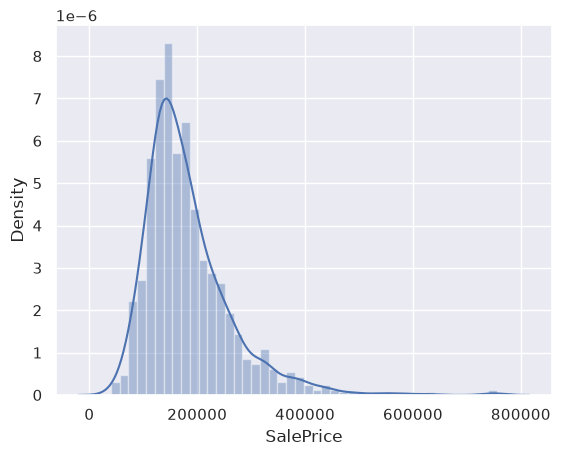

In [6]:
sns.distplot(y_train)

MSSubClass         int64
LotFrontage      float64
LotArea            int64
OverallQual        int64
OverallCond        int64
YearBuilt          int64
YearRemodAdd       int64
MasVnrArea       float64
BsmtFinSF1         int64
BsmtFinSF2         int64
BsmtUnfSF          int64
TotalBsmtSF        int64
1stFlrSF           int64
2ndFlrSF           int64
LowQualFinSF       int64
GrLivArea          int64
BsmtFullBath       int64
BsmtHalfBath       int64
FullBath           int64
HalfBath           int64
BedroomAbvGr       int64
KitchenAbvGr       int64
TotRmsAbvGrd       int64
Fireplaces         int64
GarageYrBlt      float64
GarageCars         int64
GarageArea         int64
WoodDeckSF         int64
OpenPorchSF        int64
EnclosedPorch      int64
3SsnPorch          int64
ScreenPorch        int64
PoolArea           int64
MiscVal            int64
MoSold             int64
YrSold             int64
dtype: object
MSSubClass          57.079256
LotFrontage         70.207101
LotArea          10681.630

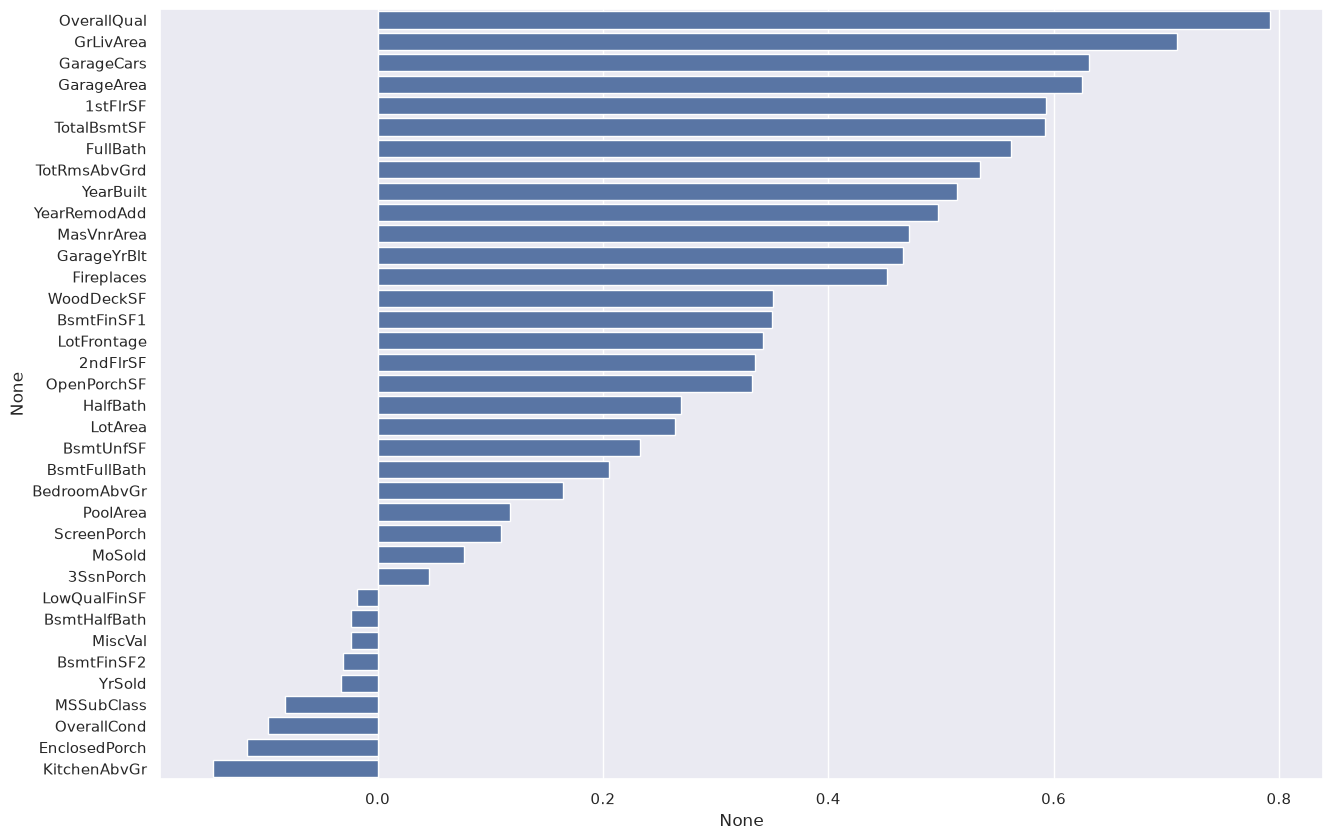

In [7]:
numeric_data = X_train.select_dtypes([np.number])
numeric_data_mean = numeric_data.mean()
numeric_features = numeric_data.columns

print(numeric_data.dtypes)
print(numeric_data_mean)
print(numeric_features)

X_train = X_train.fillna(numeric_data_mean)
X_val = X_val.fillna(numeric_data_mean)

corr = X_train[numeric_features].corrwith(y_train).sort_values(ascending=False)

plot = sns.barplot(y=corr.index, x=corr)
plot.figure.set_size_inches(15,10)

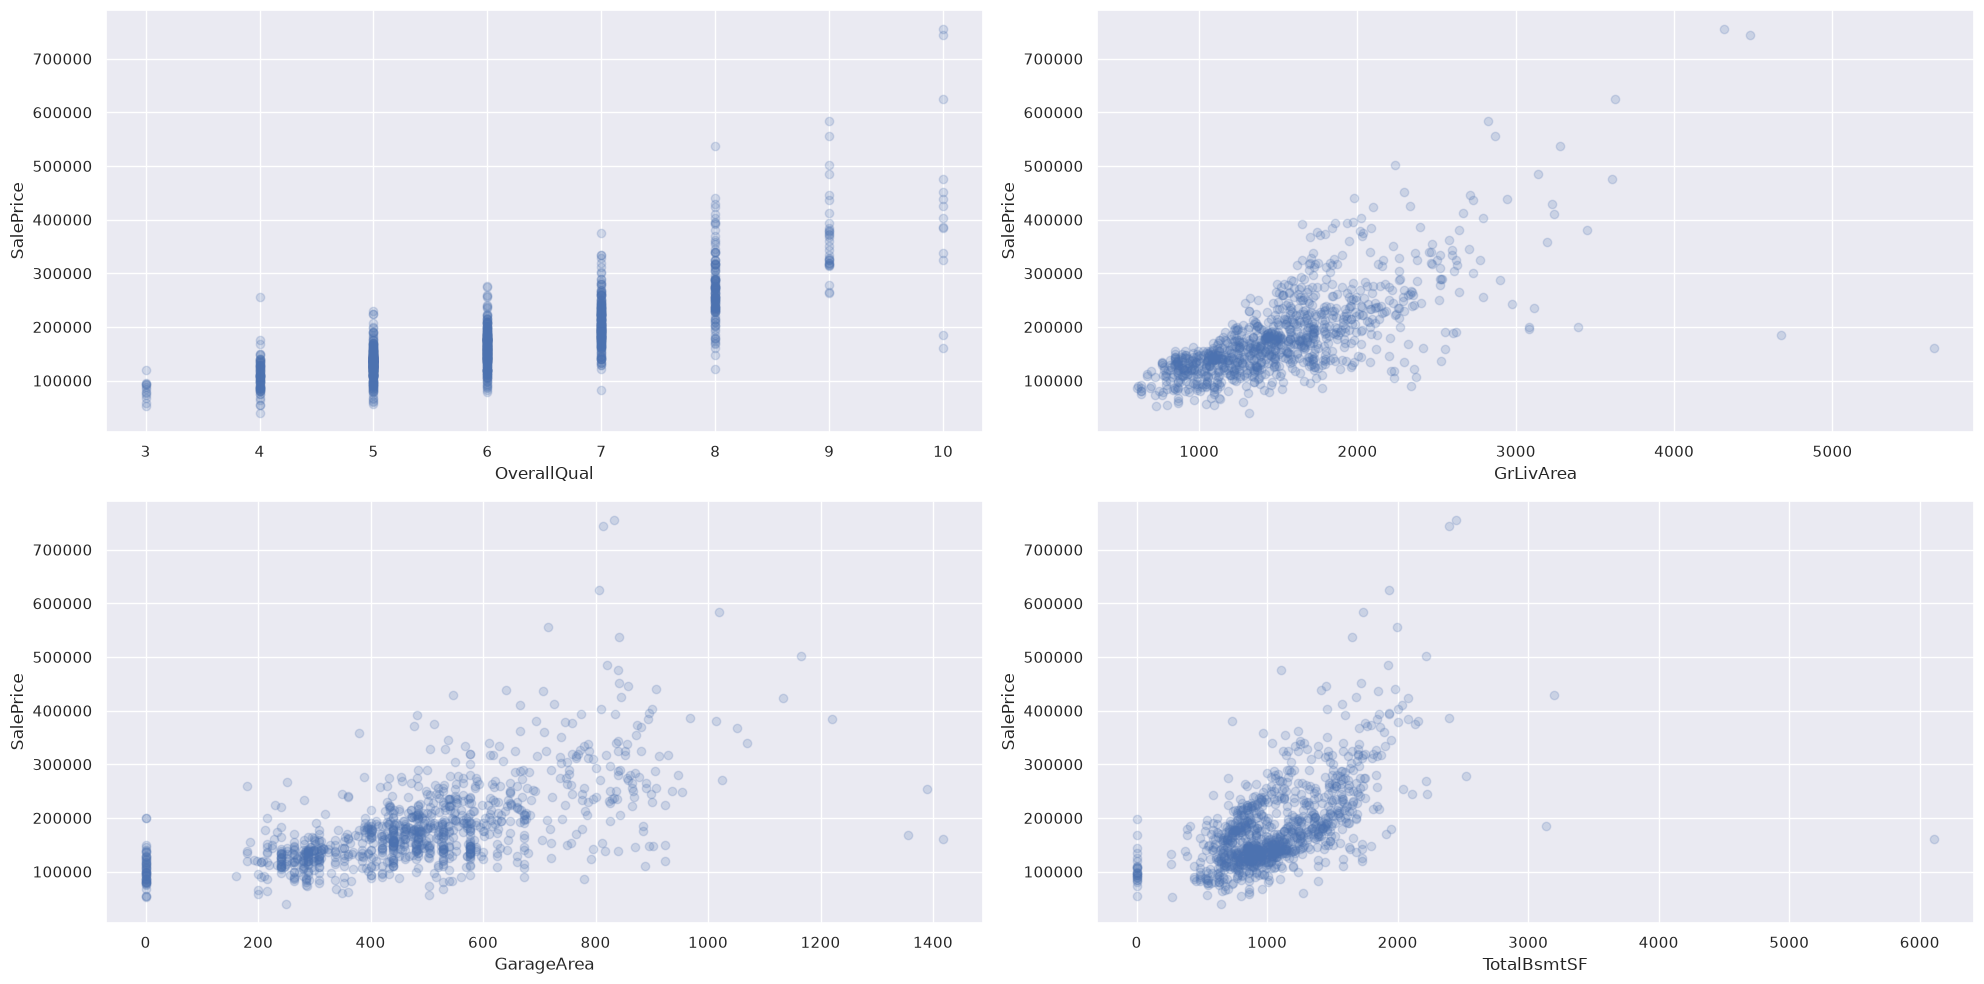

In [8]:
fig, axs = plt.subplots(figsize=(20,10), nrows=2 ,ncols=2)
for i, feature in enumerate(['OverallQual','GrLivArea', 'GarageArea', 'TotalBsmtSF']):
    axs[i//2, i%2].scatter(X_train[feature], y_train, alpha=0.2)
    axs[i//2, i%2].set_xlabel(feature)
    axs[i//2, i%2].set_ylabel('SalePrice')
plt.tight_layout()

In [9]:
from sklearn.linear_model import Ridge
from sklearn.metrics import root_mean_squared_error, r2_score

model = Ridge()
model.fit(X_train[numeric_features], y_train)
y_train_pred = model.predict(X_train[numeric_features])
y_val_pred = model.predict(X_val[numeric_features])

print('Train RMSE = %.4f' % root_mean_squared_error(y_train, y_train_pred))
print('Test RMSE = %.4f' % root_mean_squared_error(y_val, y_val_pred))

print('Train R^2 = %.4f' % r2_score(y_train, y_train_pred))
print('Test R^2 = %.4f' % r2_score(y_val, y_val_pred))

Train RMSE = 35631.3131
Test RMSE = 32085.7681
Train R^2 = 0.8045
Test R^2 = 0.8243


In [10]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X_train[numeric_features], y_train, cv=10, scoring='neg_root_mean_squared_error')
print('Mean CV RMSE = %.4f' % np.mean(-cv_scores))

Mean CV RMSE = 40156.3616


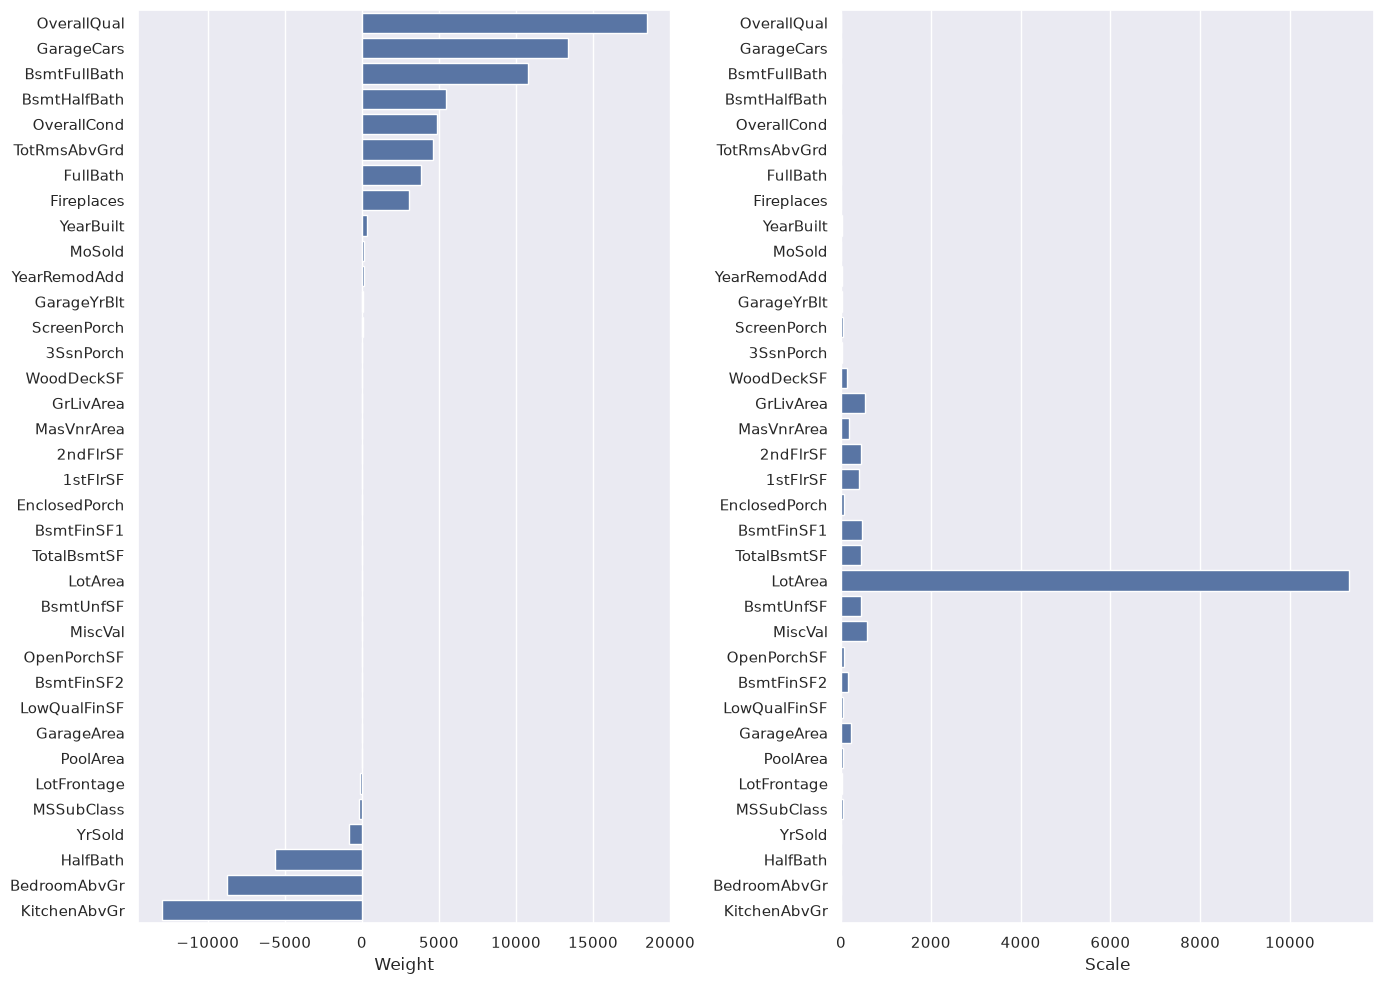

In [11]:
def show_weights(features, weights, scales):
    fig, axs = plt.subplots(figsize=(14,10), ncols=2)
    sorted_weights = sorted(zip(weights, features, scales), reverse=True)
    weights = [x[0] for x in sorted_weights]
    features = [x[1] for x in sorted_weights]
    scales = [x[2] for x in sorted_weights]
    sns.barplot(y=features, x=weights, ax=axs[0])
    axs[0].set_xlabel("Weight")
    sns.barplot(y=features, x=scales, ax=axs[1])
    axs[1].set_xlabel("Scale")
    plt.tight_layout()

show_weights(numeric_features, model.coef_, X_train[numeric_features].std())

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[numeric_features]) # fit and then transform
X_val_scaled = scaler.transform(X_val[numeric_features]) # doesn't recalculate scalers

model = Ridge()
model.fit(X_train_scaled, y_train)
y_train_pred = model.predict(X_train_scaled)
y_val_pred = model.predict(X_val_scaled)

print('Train RMSE = %.4f' % root_mean_squared_error(y_train, y_train_pred))
print('Test RMSE = %.4f' % root_mean_squared_error(y_val, y_val_pred))

print('Train R^2 = %.4f' % r2_score(y_train, y_train_pred))
print('Test R^2 = %.4f' % r2_score(y_val, y_val_pred))


Train RMSE = 35631.2160
Test RMSE = 32085.3150
Train R^2 = 0.8045
Test R^2 = 0.8243


Best alpha = 297.6351


Text(0, 0.5, 'CV score')

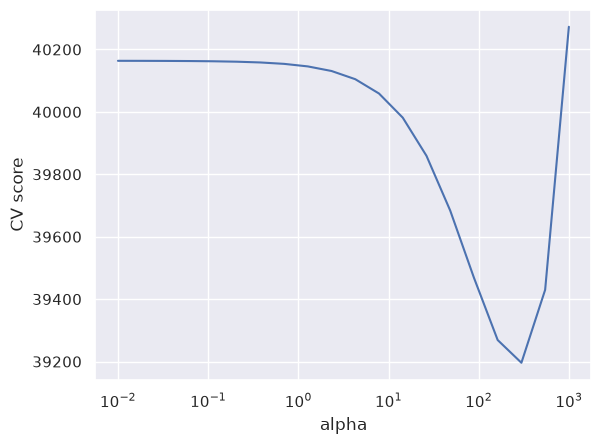

In [15]:
from sklearn.model_selection import GridSearchCV

alphas = np.logspace(-2, 3, 20)
searcher = GridSearchCV(Ridge(), [{"alpha": alphas}], scoring="neg_root_mean_squared_error", cv=10)
searcher.fit(X_train_scaled, y_train)

best_alpha = searcher.best_params_["alpha"]
print("Best alpha = %.4f" % best_alpha)

plt.plot(alphas, -searcher.cv_results_["mean_test_score"])
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("CV score")

In [16]:
from sklearn.pipeline import Pipeline

simple_pipeline = Pipeline([
    ('scaling', StandardScaler()),
    ('regression', Ridge(best_alpha))
])

model = simple_pipeline.fit(X_train[numeric_features], y_train)
y_pred = model.predict(X_val[numeric_features])
print("Test RMSE = %.4f" % root_mean_squared_error(y_val, y_val_pred))
print('Test R^2 = %.4f' % r2_score(y_val, y_val_pred))

Test RMSE = 32085.3150
Test R^2 = 0.8243


In [19]:
categorical = list(X_train.dtypes[X_train.dtypes == "object"].index)
X_train[categorical] = X_train[categorical].fillna("NotGiven")
X_val[categorical] = X_val[categorical].fillna("NotGiven")

In [44]:
X_train[categorical].sample(5)

""
196
1358
750
363
53


In [46]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown="ignore"), categorical),
    ('scaling', StandardScaler(), numeric_features)
])

pipeline = Pipeline(steps=[
    ('ohe_and_scaling', column_transformer),
    ('regression', Ridge())
])

model = pipeline.fit(X_train, y_train)
y_pred = model.predict(X_val)
print("Test RMSE = %.4f" % root_mean_squared_error(y_val, y_pred))
print("Test RMSE = %.4f" % r2_score(y_val, y_pred))

Test RMSE = 32085.3150
Test RMSE = 0.8243


In [47]:
print("Size before OneHot:", X_train.shape)
print("Size after OneHot:", column_transformer.transform(X_train).shape)

Size before OneHot: (1022, 79)
Size after OneHot: (1022, 36)


In [48]:
from sklearn.linear_model import Lasso

column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown="ignore"), categorical),
    ('scaling', StandardScaler(), numeric_features)
])

lasso_pipeline = Pipeline(steps=[
    ('ohe_and_scaling', column_transformer),
    ('regression', Lasso())
])

model = lasso_pipeline.fit(X_train, y_train)
y_pred = model.predict(X_val)
print("RMSE = %.4f" % root_mean_squared_error(y_val, y_pred))
print("Test RMSE = %.4f" % r2_score(y_val, y_pred))

RMSE = 32095.6506
Test RMSE = 0.8242


/home/artemka/projects/github/ml-models/venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.674923e+09, tolerance: 6.637e+08
  model = cd_fast.enet_coordinate_descent(


/home/artemka/projects/github/ml-models/venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.947326e+09, tolerance: 5.685e+08
  model = cd_fast.enet_coordinate_descent(
/home/artemka/projects/github/ml-models/venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.988830e+09, tolerance: 6.252e+08
  model = cd_fast.enet_coordinate_descent(
/home/artemka/projects/github/ml-models/venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, chec

Best alpha = 2335.7215


Text(0, 0.5, 'CV score')

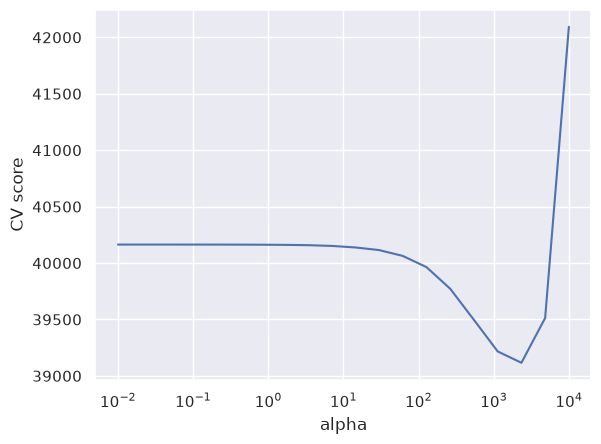

In [50]:
alphas = np.logspace(-2, 4, 20)
searcher = GridSearchCV(lasso_pipeline, [{"regression__alpha": alphas}],
                        scoring="neg_root_mean_squared_error", cv=10, n_jobs=-1)
searcher.fit(X_train, y_train)

best_alpha = searcher.best_params_["regression__alpha"]
print("Best alpha = %.4f" % best_alpha)

plt.plot(alphas, -searcher.cv_results_["mean_test_score"])
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("CV score")

In [51]:
column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown="ignore"), categorical),
    ('scaling', StandardScaler(), numeric_features)
])

pipeline = Pipeline(steps=[
    ('ohe_and_scaling', column_transformer),
    ('regression', Lasso(best_alpha))
])

model = pipeline.fit(X_train, y_train)
y_pred = model.predict(X_val)
print("Test RMSE = %.4f" % root_mean_squared_error(y_val, y_pred))
print("Test RMSE = %.4f" % r2_score(y_val, y_pred))

Test RMSE = 32690.1744
Test RMSE = 0.8176


/tmp/ipykernel_34630/1251557342.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(error)


<Axes: xlabel='SalePrice', ylabel='Density'>

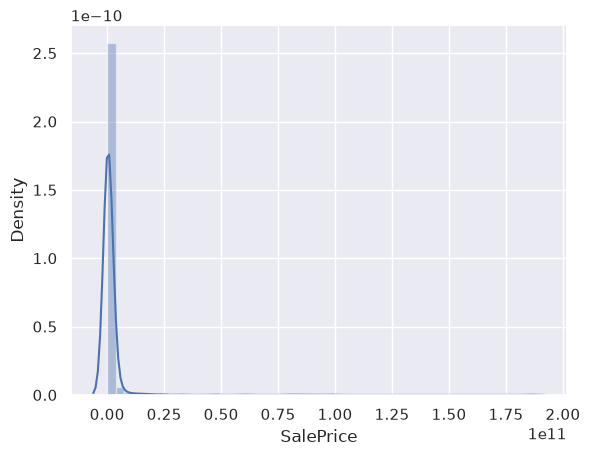

In [52]:
error = (y_train - model.predict(X_train)) ** 2
sns.distplot(error)

In [54]:
mask = (error < np.quantile(error, 0.95))
column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown="ignore"), categorical),
    ('scaling', StandardScaler(), numeric_features)
])

pipeline = Pipeline(steps=[
    ('ohe_and_scaling', column_transformer),
    ('regression', Lasso(best_alpha))
])

model = pipeline.fit(X_train[mask], y_train[mask])
y_pred = model.predict(X_val)
print("Test RMSE = %.4f" % root_mean_squared_error(y_val, y_pred))
print("Test RMSE = %.4f" % r2_score(y_val, y_pred))

Test RMSE = 32706.1475
Test RMSE = 0.8174


/tmp/ipykernel_34630/1687000731.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X_train = X_train[mask]
/tmp/ipykernel_34630/1687000731.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  error = (y_train[mask] - model.predict(X_train[mask])) ** 2
/tmp/ipykernel_34630/1687000731.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(error)


<Axes: xlabel='SalePrice', ylabel='Density'>

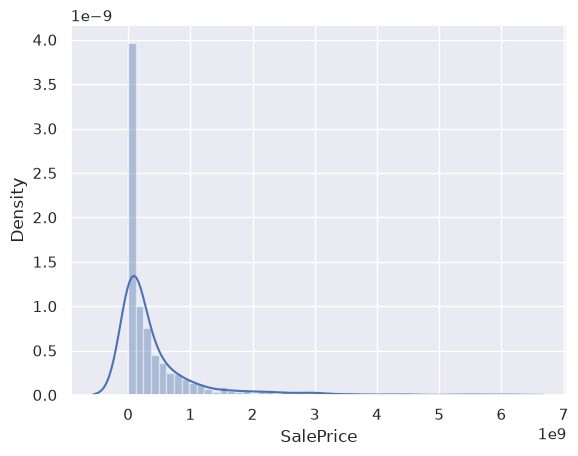

In [56]:
X_train = X_train[mask]
y_train = y_train[mask]
error = (y_train[mask] - model.predict(X_train[mask])) ** 2
sns.distplot(error)

In [59]:
column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown="ignore"), categorical),
    ('scaling', StandardScaler(), numeric_features)
])

pipeline = Pipeline(steps=[
    ('ohe_and_scaling', column_transformer),
    ('regression', Ridge())
])

model = pipeline.fit(X_train, y_train)
y_pred = model.predict(X_val)
print("Test RMSE = %.4f" % root_mean_squared_error(y_val, y_pred))
print("Test RMSE = %.4f" % r2_score(y_val, y_pred))

Test RMSE = 31173.7178
Test RMSE = 0.8341


Text(0, 0.5, 'SalePrice')

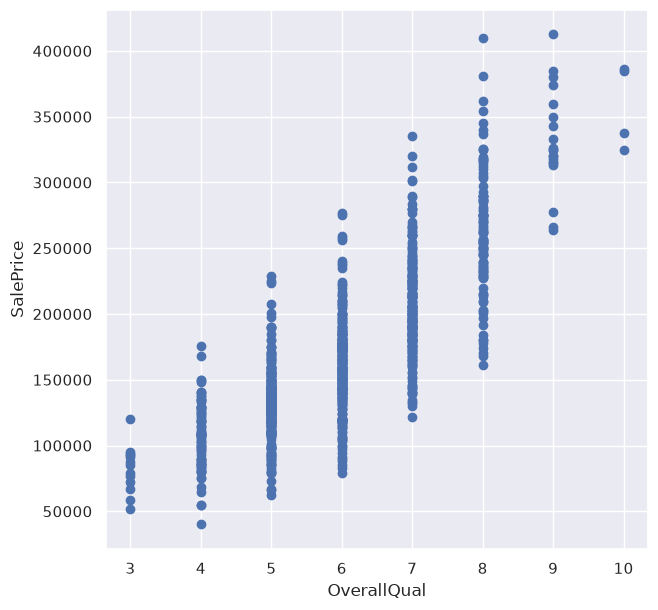

In [60]:
plt.figure(figsize=(7, 7))
plt.scatter(X_train.OverallQual, y_train)
plt.xlabel('OverallQual')
plt.ylabel('SalePrice')

In [67]:
threshold = 6
mask = (X_train.OverallQual <= threshold)
X_train_1 = X_train[mask]
y_train_1 = y_train[mask]
X_train_2 = X_train[~mask]
y_train_2 = y_train[~mask]

column_transformer1 = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown="ignore"), categorical),
    ('scaling', StandardScaler(), numeric_features)
])

pipeline1 = Pipeline(steps=[
    ('ohe_and_scaling', column_transformer1),
    ('regression', Ridge())
])

column_transformer2 = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown="ignore"), categorical),
    ('scaling', StandardScaler(), numeric_features)
])

pipeline2 = Pipeline(steps=[
    ('ohe_and_scaling', column_transformer2),
    ('regression', Ridge())
])

model1 = pipeline1.fit(X_train_1, y_train_1)
model2 = pipeline2.fit(X_train_2, y_train_2)

y_pred_1 = model1.predict(X_val)
y_pred_2 = model2.predict(X_val)
mask_test = (X_val.OverallQual <= threshold)
y_pred = y_pred_1.copy()
y_pred[~mask_test] = y_pred_2[~mask_test]

print("Test RMSE = %.4f" % root_mean_squared_error(y_val, y_pred))
print("Test RMSE = %.4f" % r2_score(y_val, y_pred))

Test RMSE = 26898.6585
Test RMSE = 0.8765


In [70]:
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.linear_model import LinearRegression

(-2.0, 2.0)

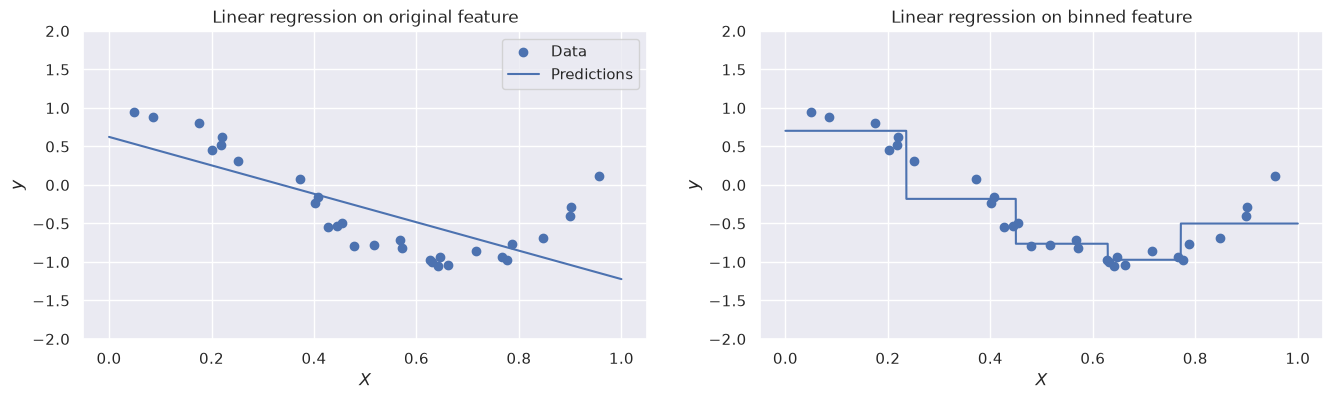

In [71]:
x_plot = np.linspace(0, 1, 10000)

X = np.random.uniform(0, 1, size=30)
y = np.cos(1.5 * np.pi * X) + np.random.normal(scale=0.1, size=X.shape)

fig, axs = plt.subplots(figsize=(16, 4), ncols=2)

regr = LinearRegression()
regr.fit(X[:, np.newaxis], y)
y_pred_regr = regr.predict(x_plot[:, np.newaxis])
axs[0].scatter(X[:, np.newaxis], y, label="Data")
axs[0].plot(x_plot, y_pred_regr, label="Predictions")
axs[0].legend()
axs[0].set_title("Linear regression on original feature")
axs[0].set_xlabel("$X$")
axs[0].set_ylabel("$y$")
axs[0].set_ylim(-2, 2)

binner = KBinsDiscretizer(n_bins=5, strategy='quantile')
pipeline = Pipeline(steps=[
    ('binning', binner),
    ('regression', LinearRegression())
])
pipeline.fit(X[:, np.newaxis], y)
y_pred_binned = pipeline.predict(x_plot[:, np.newaxis])
axs[1].scatter(X[:, np.newaxis], y, label="Data")
axs[1].plot(x_plot, y_pred_binned, label="Predictions")
axs[1].set_title("Linear regression on binned feature")
axs[1].set_xlabel("$X$")
axs[1].set_ylabel("$y$")
axs[1].set_ylim(-2, 2)

Text(0, 0.5, '$y$')

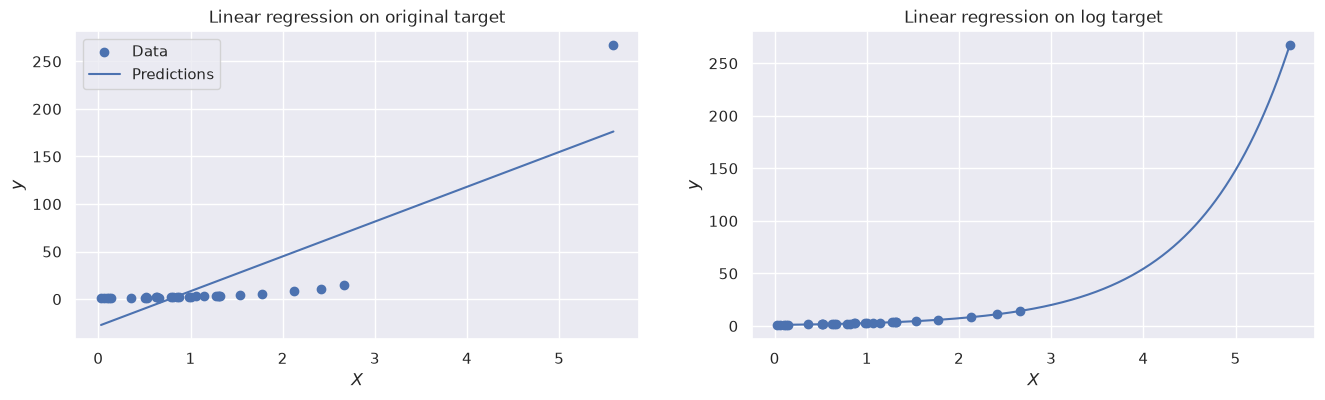

In [72]:
X = np.random.exponential(1, size=30)
y = np.exp(X) + np.random.normal(scale=0.1, size=X.shape)

x_plot = np.linspace(np.min(X), np.max(X), 10000)

fig, axs = plt.subplots(figsize=(16, 4), ncols=2)

regr = LinearRegression()
regr.fit(X[:, np.newaxis], y)
y_pred_regr = regr.predict(x_plot[:, np.newaxis])
axs[0].scatter(X[:, np.newaxis], y, label="Data")
axs[0].plot(x_plot, y_pred_regr, label="Predictions")
axs[0].legend()
axs[0].set_title("Linear regression on original target")
axs[0].set_xlabel("$X$")
axs[0].set_ylabel("$y$")

y_log = np.log(y)
regr.fit(X[:, np.newaxis], y_log)
y_pred_log = np.exp(regr.predict(x_plot[:, np.newaxis]))
axs[1].scatter(X[:, np.newaxis], y, label="Data")
axs[1].plot(x_plot, y_pred_log, label="Predictions")
axs[1].set_title("Linear regression on log target")
axs[1].set_xlabel("$X$")
axs[1].set_ylabel("$y$")